In [1]:
import numpy as np, scipy, pyvista
from tqdm.notebook import tqdm
import struct
import matplotlib.pyplot as plt
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
def solveLaplaceBeltrami2(points, triangles, boundary, move_together):
    """
    Solve laplace-beltrami equation with boundary conditions 
    """
    nPoints = len(points)
    nConstraints = len(boundary)
    L = ComputeCotangentLaplacian(points.T, triangles.T)
    
    lagrange_boundary = np.zeros((len(boundary), nPoints))
    boundary_values = np.zeros(nConstraints)
    for i, (k, v) in enumerate(boundary.items()):  
        lagrange_boundary[i, k] = 1
        boundary_values[i] = v
    
    constraints = []
    for structure in move_together:
        ref = structure[0]
        for idx in structure[1:]:
            row = np.zeros(nPoints)
            row[idx] = 1
            row[ref] = -1
            constraints.append(row)
    lagrange_together = np.array(constraints) 
    together_values = np.zeros(len(constraints)) #s_i - s_ref = 0
    
    lagrange_multipliers = np.vstack([lagrange_boundary, lagrange_together])
    rhs_values = np.concatenate([boundary_values, together_values])

    zeros = np.zeros((lagrange_multipliers.shape[0], lagrange_multipliers.shape[0]))
    L_hat = scipy.sparse.bmat([[L, lagrange_multipliers.T],[lagrange_multipliers, zeros]]).tocsr()
    b_hat = np.concatenate([np.zeros(nPoints), rhs_values])
    x_hat = scipy.sparse.linalg.spsolve(L_hat, b_hat)
    return x_hat[:nPoints]

def solveLaplaceBeltrami(points, triangles, boundary):
    """
    Solve laplace-beltrami equation with boundary conditions 
    """
    nPoints = len(points)
    nConstraints = len(boundary)
    L = ComputeCotangentLaplacian( points.T, triangles.T)
    lagrange_multipliers = np.zeros((len(boundary), nPoints))
    boundary_values = np.zeros(nConstraints)
    for i, (k, v) in enumerate(boundary.items()):  
        lagrange_multipliers[i, k] = 1
        boundary_values[i] = v
    zeros = np.zeros((nConstraints, nConstraints))
    L_hat = scipy.sparse.bmat([[L, lagrange_multipliers.T], [lagrange_multipliers, zeros]]).tocsr()
    b_hat = np.concatenate([np.zeros(nPoints), boundary_values])
    print(np.shape(L_hat))
    print(np.shape(b_hat))
    x_hat = scipy.sparse.linalg.spsolve(L_hat, b_hat)
    return x_hat[:nPoints]


def ComputeCotangentLaplacian(vertex, faces):
    """
    Calculates the laplacian of a mesh
    vertex 3xN numpy.array: vertices
    faces 3xM numpy.array: faces
    Return the Laplacian (sparse matrix probably).
    """
    n = vertex.shape[1]
    m = faces.shape[1]
    
    #compute mesh weight matrix
    W = scipy.sparse.coo_matrix((n,n))
    for i in np.arange(1,4,1):
        i1 = np.mod(i-1,3)
        i2 = np.mod(i  ,3)
        i3 = np.mod(i+1,3)
        pp = vertex[:,faces[i2,:]] - vertex[:,faces[i1,:]]
        qq = vertex[:,faces[i3,:]] - vertex[:,faces[i1,:]]
        #% normalize the vectors
        pp = pp / np.sqrt(np.sum(pp**2, axis=0))
        qq = qq / np.sqrt(np.sum(qq**2, axis=0))

        #% compute angles
        ang = np.arccos(np.sum(pp*qq, axis=0))
        W = W + scipy.sparse.coo_matrix( (1 / np.tan(ang),(faces[i2,:],faces[i3,:])), shape=(n, n) )
        W = W + scipy.sparse.coo_matrix( (1 / np.tan(ang),(faces[i3,:],faces[i2,:])), shape=(n, n) )

    W = W.tocsr()

    #compute laplacian
    d = W.sum(axis=0)
    D = scipy.sparse.dia_matrix((d, 0), shape=(n,n) )
    L = D - W

    return L

In [3]:
mesh = pyvista.PolyData('reference.vtk')
mesh.point_data['originalPointIdxMesh'] = np.arange(mesh.n_points) # So later I can get the points
surface = mesh.extract_surface()
triangles = surface.faces.reshape((-1, 4))[:, 1:]

boundary = {}
tricuspid_idx = np.where(mesh.point_data['tricuspid_valve'] == 1)[0]
no_movement_idx = np.where(mesh.point_data['wall'] == 1)[0] # Avoid repeated points 
RA_idx = np.where(mesh.point_data['RA'] == 1)[0]
IVC_idx = np.where(mesh.point_data['IVC'] == 1)[0]
SVC_idx = np.where(mesh.point_data['SVC'] == 1)[0]
FO_idx = np.where(mesh.point_data['FO'] == 1)[0]
eustachian_valve_idx = np.where(np.logical_and(mesh.point_data['eustachian_valve'] == 1,
                                               mesh.point_data['IVC'] == 0))[0] # Avoid repeated points
move_together = [IVC_idx,SVC_idx,FO_idx,eustachian_valve_idx]

for i in tricuspid_idx:
    boundary[i] = 1.0
for i in no_movement_idx:
    boundary[i] = 0.0

z = solveLaplaceBeltrami2(mesh.points.copy(), triangles, boundary, move_together)

In [4]:
# Put it back in the original order
z_mesh = np.zeros((mesh.n_points, 1))
z_mesh[mesh.point_data['originalPointIdxMesh']] = z.reshape(surface.points.shape[0], 1)
z_mesh = z_mesh**1.5
mesh.point_data['z'] = z_mesh.flatten()
mesh.save('test_mesh.vtk')

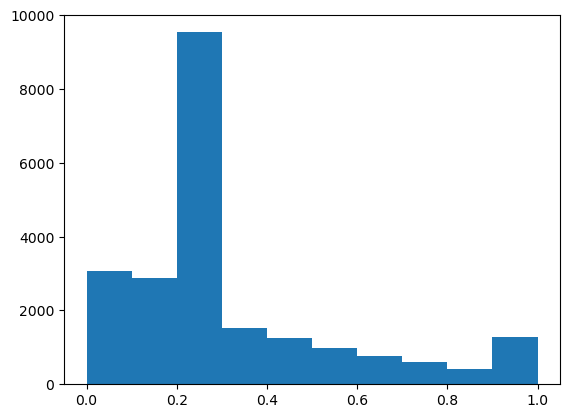

In [5]:
plt.hist(z_mesh)
plt.show()

In [6]:
def volume_error3(variable,target_volume,mesh,z_mesh,e_2,no_movement_volume,RA_idx,original_mesh):
    s_try = variable
    temp = mesh.copy()
    temp.points = original_mesh.points + s_try * z_mesh * e_2 # z_mesh: vector with heat pattern
    
    
    RA_points = temp.points[RA_idx]
    center_RA = RA_points.mean(axis=0) # RA centre

    vectors = temp.points - center_RA  
    distances = np.linalg.norm(vectors, axis=1, keepdims=True)

    radial_unit_vectors = vectors / distances # normalize: (-1, 1)

    displacement = radial_unit_vectors # displacememt as a function of distance to centre

    temp.points += -0.4 * s_try * displacement # radial movement: 40% of longitudinal movement
    
    
    vol = (temp.volume-no_movement_volume)/1000
    return (vol - target_volume)**2 

  0%|                                                  | 0/2151 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.9/site-packages/scipy/optimize/_minimize.py:892: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  warn("Method 'bounded' does not support relative tolerance in x; "
100%|███████████████████████████████████████| 2151/2151 [02:49<00:00, 12.67it/s]


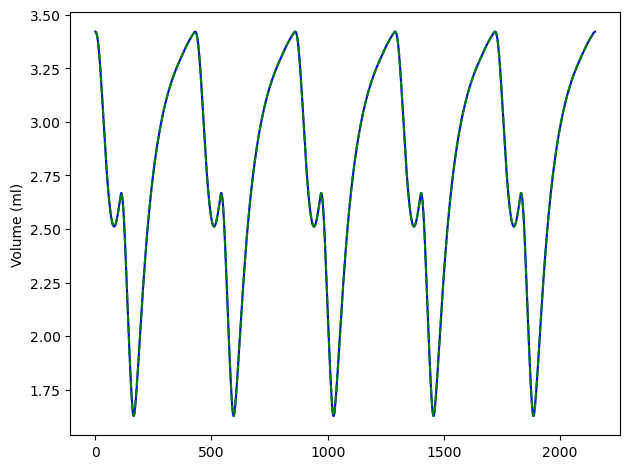

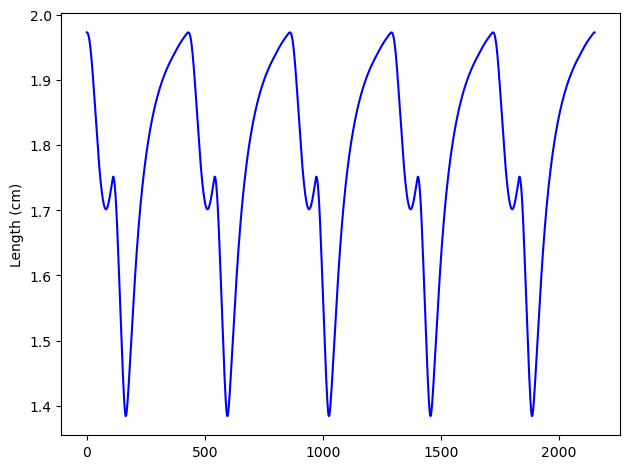

Change in length = 1.38/1.97 = 0.7
Change in diameter = 1.52/1.79 = 0.85
Change in depth = 1.52/1.79 = 0.85
Real change in length (patient MR175667 date 20250508) = 0.68
Real change in diameter (patient MR175667 date 20250508) = 0.80


In [7]:
import numpy as np
import struct
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar
from tqdm import tqdm

data = np.load(f"RA_volume.npz") # volume in a cycle (0D model) 
V_interp_orig = np.concatenate((data['data'],data['data'],data['data'],data['data'],data['data'],[data['data'][0]])) 
V_interp = V_interp_orig


N_steps = 2151
tol = 1
tv = []
volumes = []
diameters = []
lengths = []
depths = []
V_cav = []
stretch = []

mesh = pyvista.PolyData('test_mesh.vtk')
mesh_RA = pyvista.PolyData('./Meshes/RA/reference_RA.stl')
no_movement_volume = mesh.volume - mesh_RA.volume/1000 # for calculating RA volume, always subtract vessels' volume
original_mesh = pyvista.PolyData('test_mesh.vtk')

with open('RA_data_bin.dat', 'wb') as f:
    f.write(struct.pack(f'<{2}i', mesh.n_points, N_steps))
    for i in range(mesh.n_points):
        f.write(struct.pack(f'<{3}d', i+1,i+1,i+1))
    e_2 = np.array([0, 1, 0]).reshape((1, 3)) # tricuspid valve on y axis
    
    for t in tqdm(range(N_steps)):
        target_volume = V_interp[t] 

        result = minimize_scalar(
            volume_error3,
            args=(target_volume, mesh, z_mesh, e_2, no_movement_volume, RA_idx, original_mesh),
            tol=1e-3,
            bounds=(-5, 15),
            method='bounded')

        s = result.x      # movement quantity
        stretch.append(s)  

        # Apply deformation to mesh
        mesh.points = original_mesh.points + s * z_mesh * e_2
        
        RA_points = mesh.points[RA_idx]
        center_RA = RA_points.mean(axis=0)

        vectors = mesh.points - center_RA  
        distances = np.linalg.norm(vectors, axis=1, keepdims=True)

        radial_unit_vectors = vectors / distances # normalize: (-1, 1)

        displacement = radial_unit_vectors

        mesh.points += -0.4 * s * displacement
        RA_points = mesh.points[RA_idx]

        volumes.append((mesh.volume-no_movement_volume)/1000)
        tv.append(np.min(RA_points[:, 1])/10)
        diameters.append((np.max(RA_points[:, 0])-np.min(RA_points[:, 0]))/10)
        lengths.append((np.max(RA_points[:, 1])-np.min(RA_points[:, 1]))/10)
        depths.append((np.max(RA_points[:, 2])-np.min(RA_points[:, 2]))/10)
        V_cav.append(target_volume)

        # Save .vtk
        new_mesh = mesh.copy()
        new_mesh.points /= 1000
        new_mesh.save(f'./Meshes/RA_deformed_reference/RA_test_deformed_{t}.vtk') 

        # Save deformed points
        new_mesh.points.tofile(f, format='d')

# Plot results
fig, ax1 = plt.subplots()

ax1.plot(volumes, color='blue')
ax1.plot(V_cav, color='green', linestyle='--')
ax1.set_ylabel('Volume (ml)', color='black')
ax1.tick_params(axis='y', labelcolor='black')

fig.tight_layout()
plt.show()

fig, ax1 = plt.subplots()

ax1.plot(lengths, color='blue')
ax1.set_ylabel('Length (cm)', color='black')
ax1.tick_params(axis='y', labelcolor='black')

fig.tight_layout()
plt.show()

print(f"Change in length = {np.round(np.min(lengths),2)}/{np.round(np.max(lengths),2)} = {np.round(np.min(lengths)/np.max(lengths),2)}")
print(f"Change in diameter = {np.round(np.min(diameters),2)}/{np.round(np.max(diameters),2)} = {np.round(np.min(diameters)/np.max(diameters),2)}")
print(f"Change in depth = {np.round(np.min(depths),2)}/{np.round(np.max(depths),2)} = {np.round(np.min(depths)/np.max(depths),2)}")

print(f"Real change in length (patient MR175667 date 20250508) = 0.68")
print(f"Real change in diameter (patient MR175667 date 20250508) = 0.80")

In [8]:
import os
import pyvista as pv

# Folder containing .vtk files
input_folder = "./Meshes/RA_deformed_reference/"

# Folder containing .stl files
output_folder = "./Meshes/RA_deformed_reference_stl/"

# Create the output folder if it does not exist
os.makedirs(output_folder, exist_ok=True)

# Browse through all the files in the inbox folder
for filename in os.listdir(input_folder):
    if filename.endswith(".vtk"):
        vtk_path = os.path.join(input_folder, filename)
        
        # Read .vtk file
        mesh = pv.read(vtk_path)
        
        # Change extension to .stl
        stl_filename = os.path.splitext(filename)[0] + ".stl"
        stl_path = os.path.join(output_folder, stl_filename)
        
        # Save as STL
        mesh.save(stl_path)


In [9]:
import pyvista as pv
import numpy as np
import glob
import re
import os

# Search for all .vtk files in the folder
vtk_files = glob.glob("./Meshes/RA_deformed_reference/*.vtk")

def extract_number(filename):
    match = re.search(r'(\d+)(?=\.vtk$)', os.path.basename(filename))
    return int(match.group(1)) if match else -1

# Sort the files in ascending numerical order
vtk_files.sort(key=extract_number)
areas = []
volumes = []

# Read meshes
all_points = []
for file in vtk_files:
    mesh = pv.read(file)
    print(file)
    all_points.append(mesh.points.flatten())
    submesh = None
    if "tricuspid_valve" in mesh.array_names:
        mask = mesh["tricuspid_valve"] > 0  
        submesh = mesh.extract_points(mask)

    areas.append(submesh.area/1e-4)
    volumes.append(mesh.volume)

n_points = mesh.points.shape[0]

indices = np.arange(1, n_points + 1)
header = np.repeat(indices, 3)


# Save .dat file
with open("dynamicmesh_reference.dat", "w") as f:
    # First row: number of VTK files
    f.write(f"{len(vtk_files)}\n")
    # Second row: n_points * 3
    f.write(f"{n_points*3}\n")
    # Row of indices
    np.savetxt(f, header.reshape(1, -1), fmt="%d", delimiter="\t")
    # Coordinates
    np.savetxt(f, all_points, fmt="%.6f", delimiter="\t")



./Meshes/RA_deformed_reference/RA_test_deformed_0.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_2.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_3.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_4.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_5.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_6.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_7.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_8.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_9.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_10.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_11.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_12.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_13.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_14.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_15.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_16.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_17.vtk
./Meshes/RA_deformed

./Meshes/RA_deformed_reference/RA_test_deformed_149.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_150.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_151.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_152.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_153.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_154.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_155.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_156.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_157.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_158.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_159.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_160.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_161.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_162.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_163.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_164.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_165.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_

./Meshes/RA_deformed_reference/RA_test_deformed_320.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_321.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_322.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_323.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_324.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_325.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_326.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_327.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_328.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_329.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_330.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_331.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_332.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_333.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_334.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_335.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_336.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_

./Meshes/RA_deformed_reference/RA_test_deformed_485.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_486.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_487.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_488.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_489.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_490.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_491.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_492.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_493.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_494.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_495.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_496.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_497.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_498.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_499.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_500.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_501.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_

./Meshes/RA_deformed_reference/RA_test_deformed_632.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_633.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_634.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_635.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_636.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_637.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_638.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_639.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_640.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_641.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_642.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_643.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_644.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_645.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_646.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_647.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_648.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_

...

./Meshes/RA_deformed_reference/RA_test_deformed_1396.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1397.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1398.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1399.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1400.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1401.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1402.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1403.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1404.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1405.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1406.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1407.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1408.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1409.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1410.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1411.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1412.vtk
./Meshes/RA_deformed_reference/

./Meshes/RA_deformed_reference/RA_test_deformed_1546.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1547.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1548.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1549.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1550.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1551.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1552.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1553.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1554.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1555.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1556.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1557.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1558.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1559.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1560.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1561.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1562.vtk
./Meshes/RA_deformed_reference/

./Meshes/RA_deformed_reference/RA_test_deformed_1708.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1709.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1710.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1711.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1712.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1713.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1714.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1715.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1716.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1717.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1718.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1719.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1720.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1721.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1722.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1723.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1724.vtk
./Meshes/RA_deformed_reference/

./Meshes/RA_deformed_reference/RA_test_deformed_1860.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1861.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1862.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1863.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1864.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1865.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1866.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1867.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1868.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1869.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1870.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1871.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1872.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1873.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1874.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1875.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_1876.vtk
./Meshes/RA_deformed_reference/

./Meshes/RA_deformed_reference/RA_test_deformed_2012.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_2013.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_2014.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_2015.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_2016.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_2017.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_2018.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_2019.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_2020.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_2021.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_2022.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_2023.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_2024.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_2025.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_2026.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_2027.vtk
./Meshes/RA_deformed_reference/RA_test_deformed_2028.vtk
./Meshes/RA_deformed_reference/

66900


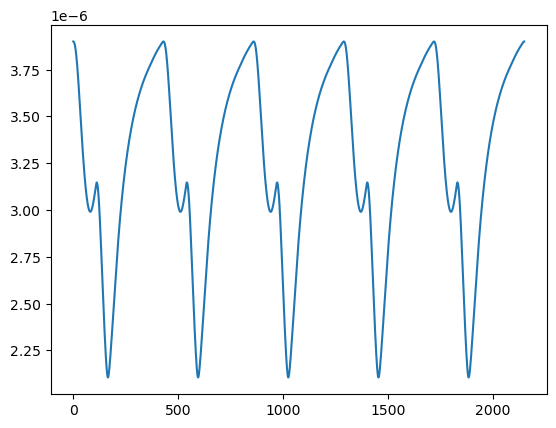

In [10]:
plt.plot(volumes)
print(n_points*3) # 66900

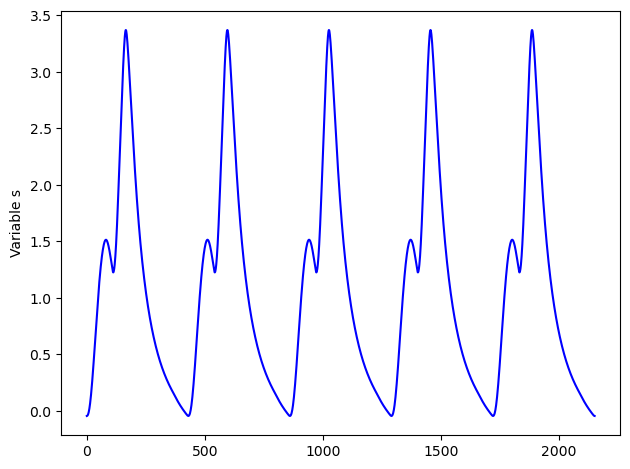

In [11]:
fig, ax1 = plt.subplots()

ax1.plot(stretch, color='blue')
ax1.set_ylabel('Variable s', color='black')
ax1.tick_params(axis='y', labelcolor='black')

fig.tight_layout()
plt.show()